In [5]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

In [6]:
sim = Simulation("DarkSignal")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Noise

In [7]:
sim["CCD/DarkSignal/Stability"] = 0
sim["CCD/DarkSignal/DSNU"] = 0

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

sim["CCD/IncludeDarkSignal"] = "yes"
outputWithDark = sim.run(removeOutputFile = True)
imageWithDark = outputWithDark.getImage(0)

sim["CCD/IncludeDarkSignal"] = "no"
outputWithoutDark = sim.run(removeOutputFile = True)
imageWithoutDark = outputWithoutDark.getImage(0)

dark = imageWithDark - imageWithoutDark


2020-05-18 13:33:46 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:33:46 WARNING Camera: No star positions to write to HDF5 file.


2020-05-18 13:33:47 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:33:47 WARNING Camera: No star positions to write to HDF5 file.



In [10]:
expectedDarkSignal = sim["ObservingParameters/CycleTime"] * sim["CCD/DarkSignal/DarkCurrent"]

(5, 55)

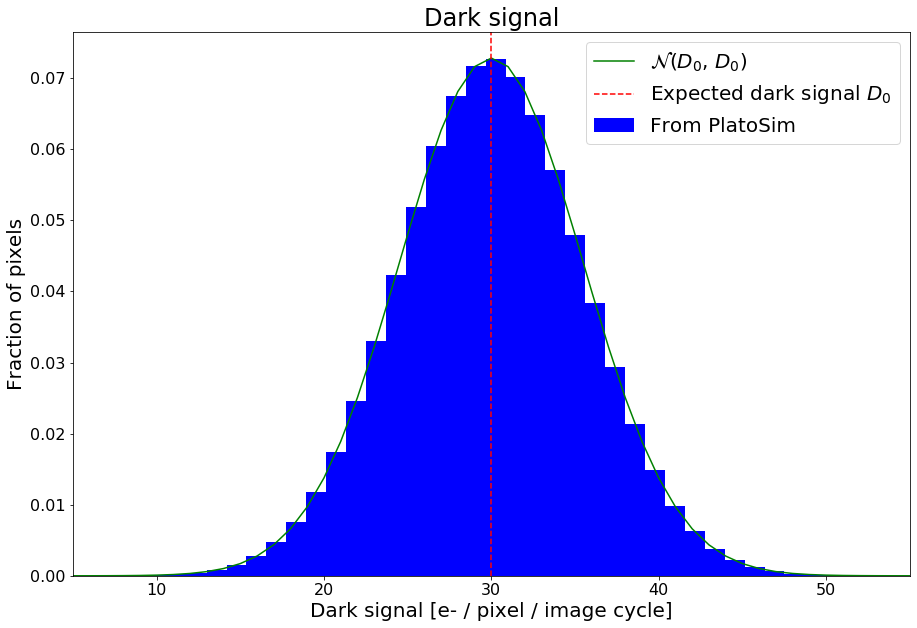

In [12]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.hist(dark.ravel(), 50, density = True, color = "b", label = "From PlatoSim")



#####################
# Normal distribution
#####################

mu = expectedDarkSignal
sigma = math.sqrt(expectedDarkSignal)
x = np.arange(0, 60)
label = "$\mathcal{N}$($D_0$, $D_0$)"
plt.plot(x, stats.norm.pdf(x, mu, sigma), "g", label = label)

plt.axvline(x = expectedDarkSignal, color = "r", linestyle = "dashed", label = "Expected dark signal $D_0$")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Dark signal [e- / pixel / image cycle]", fontsize = 20)
plt.ylabel("Fraction of pixels", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([5, 55])

In [13]:
meanFromDarkMap = np.mean(dark)
stdDevFromDarkMap = np.std(dark)

print("Mean from dark map:", meanFromDarkMap)
print("To compare with expected value:", mu, "\n")

print("Standard deviation from dark map:", stdDevFromDarkMap)
print("To compare with input value in the configuration file:", sigma)

Mean from dark map: 29.999638
To compare with expected value: 30.0 

Standard deviation from dark map: 5.475559
To compare with input value in the configuration file: 5.477225575051661


# DSNU

In [14]:
sim["CCD/DarkSignal/DSNU"] = 15

# Single-pixel exposures

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

cycleTime = sim["ObservingParameters/CycleTime"]
expectedDarkSignal = sim["CCD/DarkSignal/DarkCurrent"] * cycleTime

# sim["CCD/DarkSignal/DSNU"] = 0
dsnu = sim["CCD/DarkSignal/DSNU"] / 100.0

In [15]:
sim["CCD/DarkSignal/Stability"] = 0

# Enable dark signal

sim["CCD/IncludeDarkSignal"] = "yes"
outputWithDark = sim.run(removeOutputFile = True)

# Disable dark signal

sim["CCD/IncludeDarkSignal"] = "no"
outputWithoutDark = sim.run(removeOutputFile = True)


2020-05-18 13:36:39 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:36:39 WARNING Camera: No star positions to write to HDF5 file.


2020-05-18 13:36:44 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:36:44 WARNING Camera: No star positions to write to HDF5 file.



In [16]:
dark = np.array([])

for exposure in range(numExposures):
    
    dark = np.append(dark, outputWithDark.getImage(exposure)[0][0] - outputWithoutDark.getImage(exposure)[0][0])

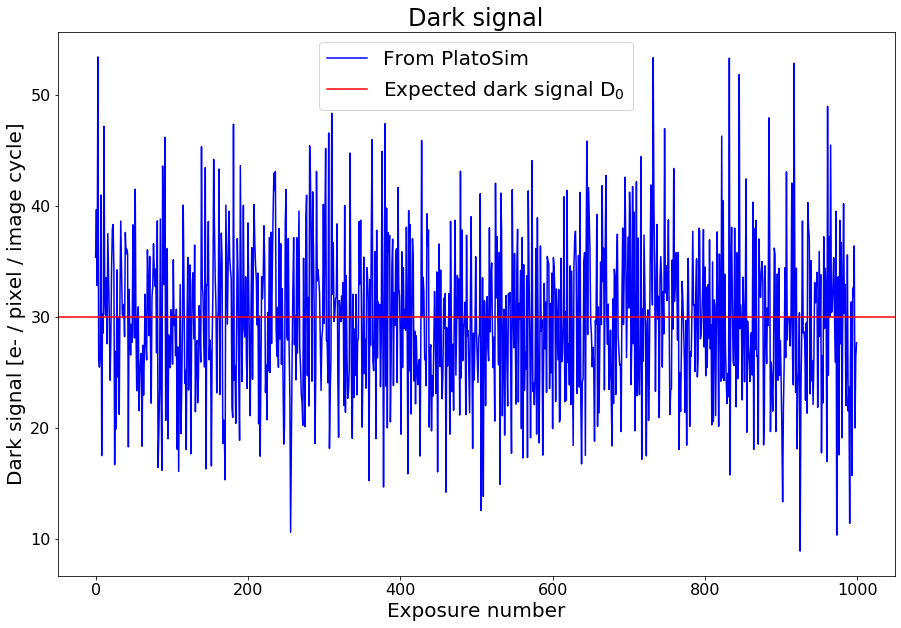

In [17]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(dark, "b", label = "From PlatoSim")



#########
# Average
#########

plt.axhline(y = expectedDarkSignal, color = "r", label = "Expected dark signal D$_0$")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Dark signal [e- / pixel / image cycle]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

(5, 55)

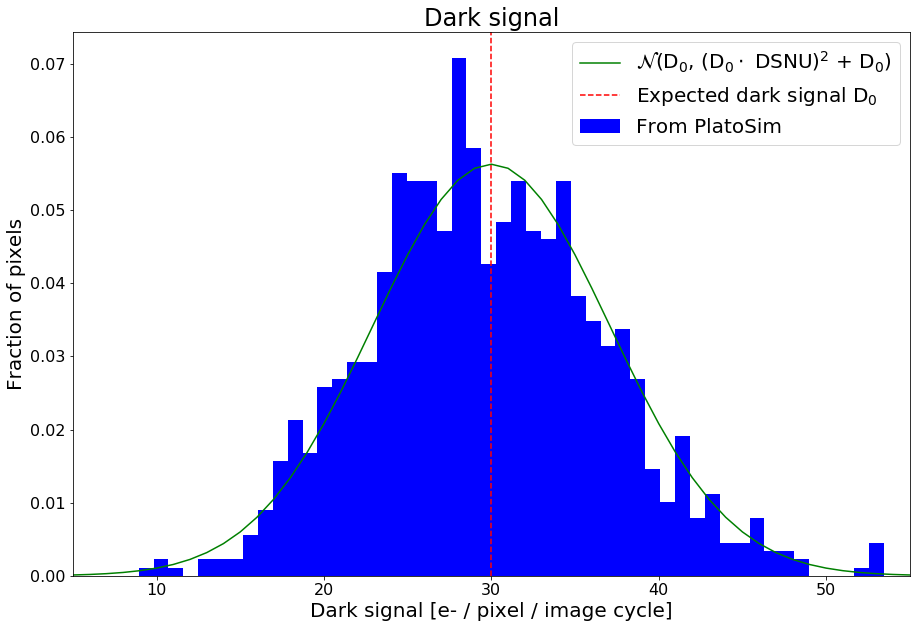

In [18]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.hist(dark, 50, density = True, color = "b", label = "From PlatoSim")



#####################
# Normal distribution
#####################

mu = expectedDarkSignal
# sigma = expectedDarkSignal * dsnu
sigma = math.sqrt(math.pow(expectedDarkSignal * dsnu, 2) + math.pow(math.sqrt(expectedDarkSignal), 2))
x = np.arange(0, 60)
label = "$\mathcal{N}$(D$_0$, (D$_0 \cdot$ DSNU)$^2$ + D$_0$)"
plt.plot(x, stats.norm.pdf(x, mu, sigma), "g", label = label)

plt.axvline(x = expectedDarkSignal, color = "r", linestyle = "dashed", label = "Expected dark signal D$_0$")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Dark signal [e- / pixel / image cycle]", fontsize = 20)
plt.ylabel("Fraction of pixels", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([5, 55])

In [19]:
meanFromDarkMap = np.mean(dark)
stdDevFromDarkMap = np.std(dark)

print("Mean from dark map:", meanFromDarkMap)
print("To compare with expected value:", mu, "\n")

print("Standard deviation from dark map:", stdDevFromDarkMap)
print("To compare with expected value:", sigma)

Mean from dark map: 29.72458642578125
To compare with expected value: 30.0 

Standard deviation from dark map: 7.025149748499035
To compare with expected value: 7.088723439378913


# Temperature stability

In [20]:
numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures

time = np.array([0, numExposures * cycleTime])
sim["ObservingParameters/NumExposures"] = numExposures - 2
deltaTemperature = 1
temperature = np.array([sim["CCD/NominalOperatingTemperature"], sim["CCD/NominalOperatingTemperature"] + deltaTemperature])

sim["CCD/IncludeDarkSignal"] = "yes"
sim["CCD/DarkSignal/Stability"] = 5.0
sim["CCD/DarkSignal/DSNU"] = 0

sim["CCD/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["CCD/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

outputWithDark = sim.run(removeOutputFile = True)


2020-05-18 13:37:01 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-18 13:37:01 WARNING Camera: No star positions to write to HDF5 file.



In [21]:
dark = np.array([])

for exposure in range(numExposures - 2):
    
    dark = np.append(dark, outputWithDark.getImage(exposure)[0][0] - outputWithoutDark.getImage(exposure)[0][0])

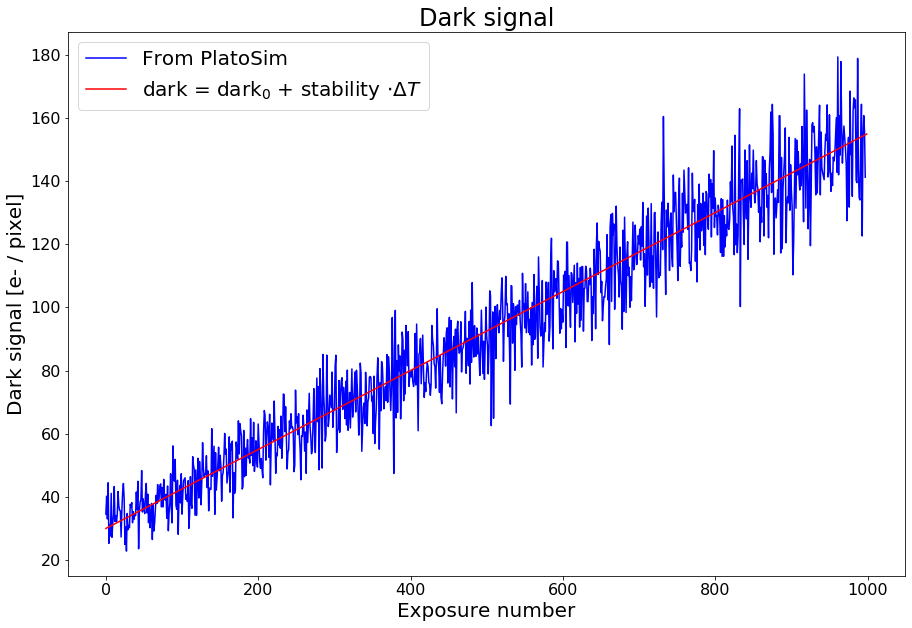

In [22]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.plot(dark, color = "b", label = "From PlatoSim")



#############################################################
# Linear increase in dark signal with increase in temperature
#############################################################


slope = (temperature[-1] - temperature[0]) / (numExposures) * sim["CCD/DarkSignal/Stability"] * cycleTime
exposures = np.arange(0, numExposures)
plt.plot(expectedDarkSignal + slope * exposures, "r", label = "dark = dark$_0$ + stability $\\cdot \\Delta T$")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Dark signal [e- / pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)